# Generate functions using the Fourier sine series

## Goal
Have a method to create functions of varying degrees of continuous differentiability. Use these for testing and validation of quantics tensor train approximations and get estimates of rank requirements. Here we display a prototype implementation.

## Method
Randomly generate coefficients of the Fourier sine series, and scale these by varying decay factors. Normalize these coefficients to have consistent total energy across function types. This is necessary to perform error analysis later. Generate the time-domain (discretized) function via inverse discrete sine transform of type 1.

## Result
Below, we show this for $O(1), O(1/n), O(1/n^2), O(1/n^3)$.

In [5]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [9]:
def rand_func1d_sine_basis(decay_rate, nBit, rng):
    '''
    Use the inverse discrete sine transform to generate a random function

    Args:
        decay_rate: Have sine series coefficients decay at rate n**(-decay_rate)
        nBit: Number of bits to represent a grid point, as in a quantics representation. Grid size is 2**nBit
        rng: Random number generator
    '''
    N = 2**nBit
    coeff = rng.uniform(-0.5, 0.5, N) * np.arange(1, N + 1, dtype=complex)**(-decay_rate)
    # normalize the total energy so that error analysis can be applied later
    coeff /= np.linalg.norm(coeff)
    
    # Perform inverse sine transform
    h = scipy.fft.idst(coeff, type=1, norm='ortho')

    return h, coeff

In [10]:
L = 10

In [11]:
rng = np.random.default_rng()
f0, F0 = rand_func1d_sine_basis(0, L, rng)

In [12]:
xs = np.linspace(0, 1, 2**L, endpoint=False)

<StemContainer object of 3 artists>

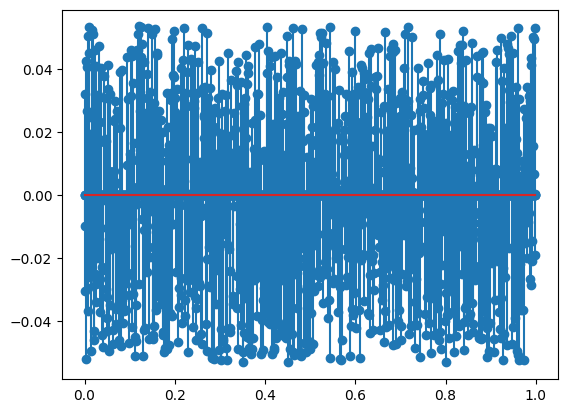

In [13]:
plt.stem(xs, F0.real)
plt.stem(xs, F0.imag)

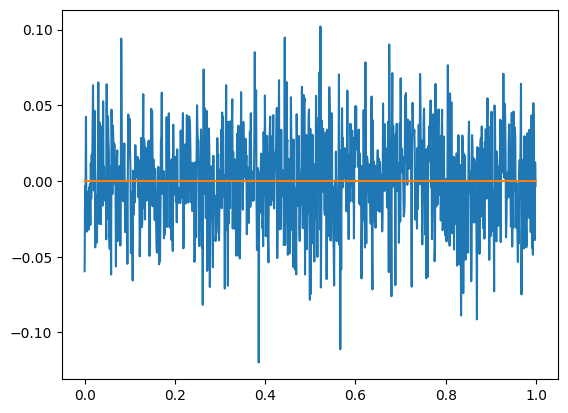

In [14]:
plt.plot(xs, f0.real)
plt.plot(xs, f0.imag)

In [16]:
f1, F1 = rand_func1d_sine_basis(1, L, rng)

/Users/spencer/Projects/QTT/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/spencer/Projects/QTT/.venv/lib/python3.13/site-packages/numpy/ma/core.py:3452: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/Users/spencer/Projects/QTT/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<StemContainer object of 3 artists>

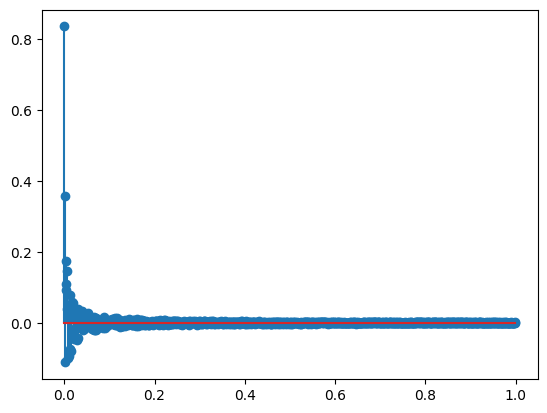

In [17]:
plt.stem(xs, F1)

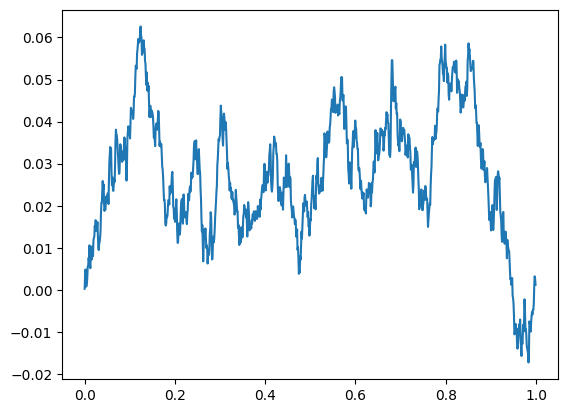

In [18]:
plt.plot(xs, f1)

In [20]:
f2, F2 = rand_func1d_sine_basis(2, L, rng)

<StemContainer object of 3 artists>

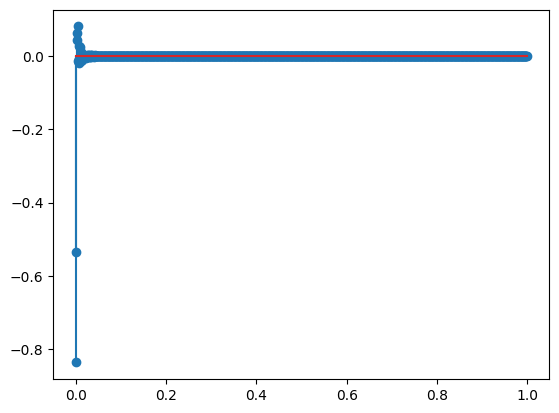

In [21]:
plt.stem(xs, F2)

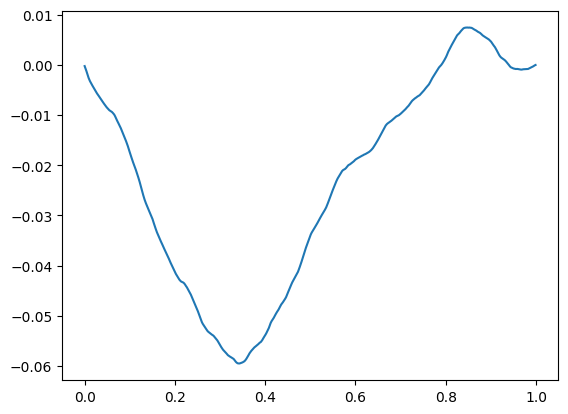

In [22]:
plt.plot(xs, f2)

<StemContainer object of 3 artists>

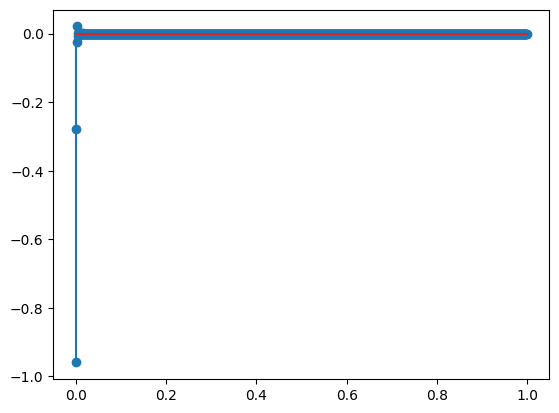

In [23]:
f3, F3 = rand_func1d_sine_basis(3, L, rng)
plt.stem(xs, F3)

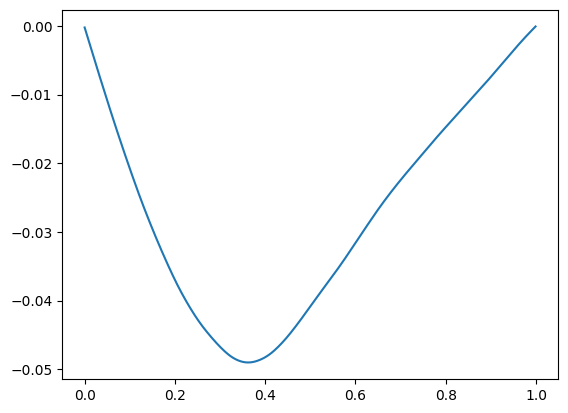

In [24]:
plt.plot(xs, f3)